In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import category_encoders as ce
import missingno as msno
from sklearn.impute import SimpleImputer

def load_data():
    data = pd.read_csv("../Data/term-deposit-marketing-2020.csv")
    df = data.copy()
    return df


df.head()

NameError: name 'df' is not defined

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y'],
      dtype='object')

# Feature engineering

# Nominal variables

In [ ]:
def binary_vars(df):
    df['default'] = df['default'].map({'yes': 1, 'no': 0})
    df['housing'] = df['housing'].map({'yes': 1, 'no': 0})
    df['loan'] = df['loan'].map({'yes': 1, 'no': 0})
    df['y'] = df['y'].map({'yes': 1, 'no': 0})
    retun df

In [ ]:
def na_vars(df):
    df["education"] = df["education"].replace("unknown", np.nan)
    df["job"] = df["job"].replace("unknown", np.nan)
    df["contact"] = df["contact"].replace("unknown", np.nan)
    return df

In [ ]:
def mapping_vars(df):
    df['job'] = df['job'].map({'management':0,'technician':1,'entrepreneur':2, 'blue-collar':3,
            'retired': 4, 'admin': 5,  'services': 6, 'self-employed': 7,
            'unemployed': 8,  'housemaid': 9, 'student': 10 })

    df['marital'] = df['marital'].map({'single':0,'married':1,'divorced':2})
    df['contact'] = df['contact'].map({'cellular': 0, 'telephone': 1})
    return df

In [24]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,0.0,1,2,0,2143,1,0,0.0,5,5,261,1,0
1,44,1.0,0,1,0,29,1,0,0.0,5,5,151,1,0
2,33,2.0,1,1,0,2,1,1,0.0,5,5,76,1,0
3,47,3.0,1,1,0,1506,1,0,0.0,5,5,92,1,0
4,33,3.0,0,1,0,1,0,0,0.0,5,5,198,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,1.0,1,2,0,395,0,0,0.0,3,6,107,1,0
39996,30,0.0,0,2,0,3340,0,0,0.0,3,6,238,3,1
39997,54,5.0,2,1,0,200,0,0,0.0,3,6,170,1,1
39998,34,0.0,1,2,0,1047,0,0,0.0,3,6,342,1,0


# Dealing with Ordinal data

In [ ]:
def ordinal_mapping(df):
    education_encoder= ce.OrdinalEncoder(cols=['education'],return_df=True,
                            mapping=[{'col':'education',
    'mapping':{'primary': 0,'secondary': 1,'tertiary': 2}}])
    
    month_encoder= ce.OrdinalEncoder(cols=['month'],return_df=True,
                            mapping=[{'col':'month',
    'mapping':{'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5,
            'jun': 6, 'jul': 7, 'aug': 8, 'oct': 10, 'nov': 11, 'dec': 12}}])
    df[['education']] = education_encoder.fit_transform(df[['education']]).astype('int')
        #[[]] used to indicate dataframe not series
    df[['month']] = month_encoder.fit_transform(df[['month']]).astype('int')
    return df

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        40000 non-null  int64  
 1   job        40000 non-null  float64
 2   marital    40000 non-null  int64  
 3   education  40000 non-null  int64  
 4   default    40000 non-null  int64  
 5   balance    40000 non-null  int64  
 6   housing    40000 non-null  int64  
 7   loan       40000 non-null  int64  
 8   contact    40000 non-null  float64
 9   day        40000 non-null  int64  
 10  month      40000 non-null  int64  
 11  duration   40000 non-null  int64  
 12  campaign   40000 non-null  int64  
 13  y          40000 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 4.3 MB


# EDA

# Dealing with missing data

In [ ]:
def missing_data(df):
    missing = df.isna().sum()/len(df)
    matrix_missing = msno.matrix(df)
    heatmap_missing = msno.heatmap(df)
    return missing, matrix_missing, heatmap_missing

age          0.000000
job          0.005875
marital      0.000000
education    0.038275
default      0.000000
balance      0.000000
housing      0.000000
loan         0.000000
contact      0.319125
day          0.000000
month        0.000000
duration     0.000000
campaign     0.000000
y            0.000000
dtype: float64

Some missingness exists across three variables, but the reason for the missing values is still unclear. The heatmap does not reveal much, showing only a very weak positive correlation in missingness between job and education (0.2) and between contact and education (0.1)

In [17]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

Using mode imputation for the contact variable may introduce bias because approximately 32% of its values are missing. Replacing such a large proportion with the most frequent category could significantly distort the original distribution. In contrast, the missingness in education (around 4%) and job (around 0.06%) is very small, so mode imputation for these two variables is less likely to affect the model.

# Outlier analysis 

he distributions help determine which outlier detection method is most appropriate. The Z-score method may not be suitable, as more than three numeric variables are strongly right-skewed, while Z-score-based outlier detection works best with approximately normally distributed data. Therefore, the quantile/IQR method is preferred because it is more robust to skewed distributions and extreme values. The differences in the ranges and distributions of the numeric variables may also indicate the need for feature scaling later, depending on the machine-learning model used.

<Axes: xlabel='age', ylabel='Count'>

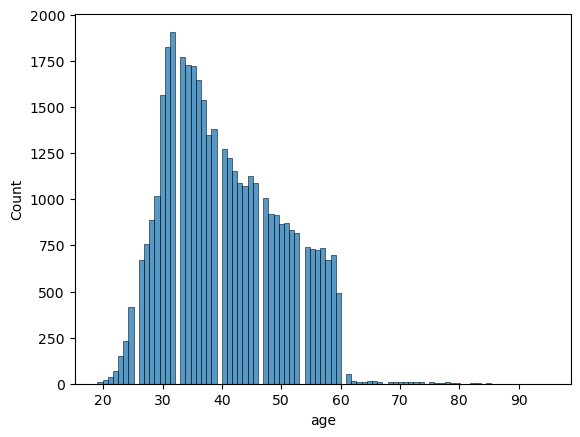

In [ ]:
def histgrams():
    age = sns.histplot(df['age'])
    plt.show()
    balance = sns.histplot(df['balance'])
    plt.show()
    duration = sns.histplot(df['duration'])
    plt.show()
    day = sns.histplot(df['day'])
    plt.show()
    return age, balance, duration, day

<Axes: xlabel='day', ylabel='Count'>

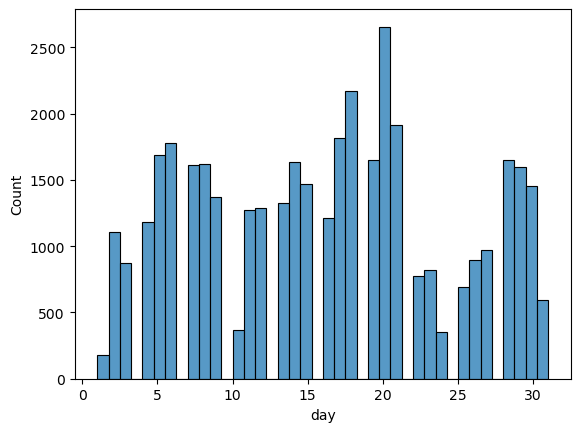

In [20]:
sns.histplot(df['day'])

In [21]:
def outlier_analysis(df, column):
    q1_q = df[column].quantile(0.25)
    q3_q = df[column].quantile(0.75)
    # Find the IQR
    IQR = q3_q - q1_q
    factor = 2.5 # 2.5 × IQR means you only mark really extreme points as outliers
    lower_limit_q = q1_q - IQR*factor
    upper_limit_q = q3_q + IQR*factor

    is_lower_q = df[column] < lower_limit_q

    is_higher_q = df[column] > upper_limit_q
    # Combine the masks to filter for outliers
    outliers = df[column][is_lower_q | is_higher_q] 
    # Count and print the number of outliers
    print(len(outliers))
    return outliers

In [22]:
age_outliers = outlier_analysis(df,"age")
duration_outliers = outlier_analysis(df,"duration")
day_outiers = outlier_analysis(df,"day") 
balance_outliers = outlier_analysis(df,"balance")

4
1514
0
2761


In [9]:
def correlation_matrix():
    corr = df.select_dtypes(include='number').corr()
    plt.figure(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr))
    correlation_matrix = sns.heatmap(corr, center=0,
            mask=mask,
              linewidths=1,
              annot=True,
                fmt=".2f"
)
    plt.title("Correlation matrix")
    plt.show()
    return correlation_matrix

No strong correlations were observed between the numeric variables. The highest correlation was 46% between the duration of the last contact (in seconds) and whether the client subscribed to a term deposit, followed by a 39% correlation between marital status and age.

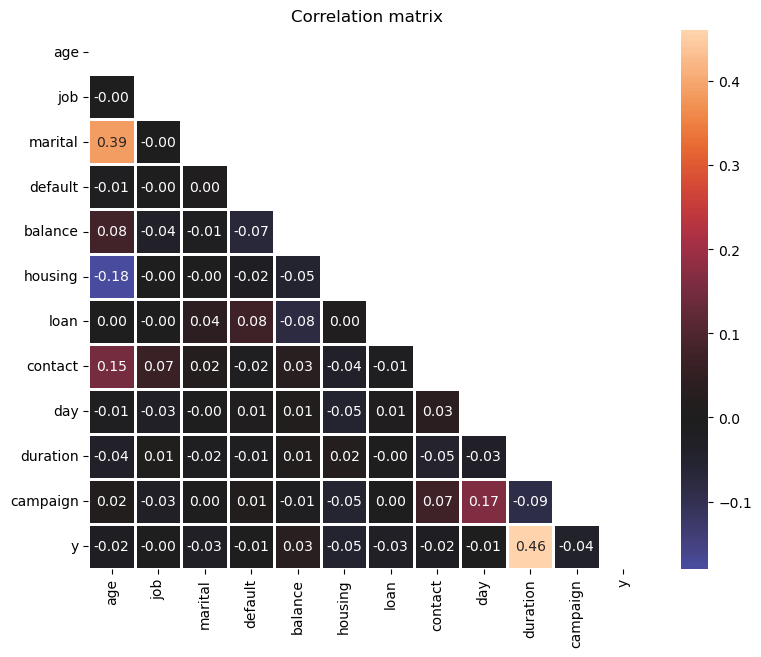

<Axes: title={'center': 'Correlation matrix'}>

In [10]:
correlation_matrix()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        40000 non-null  int64  
 1   job        39765 non-null  float64
 2   marital    40000 non-null  int64  
 3   education  38469 non-null  object 
 4   default    40000 non-null  int64  
 5   balance    40000 non-null  int64  
 6   housing    40000 non-null  int64  
 7   loan       40000 non-null  int64  
 8   contact    27235 non-null  float64
 9   day        40000 non-null  int64  
 10  month      40000 non-null  object 
 11  duration   40000 non-null  int64  
 12  campaign   40000 non-null  int64  
 13  y          40000 non-null  int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 4.3+ MB


In [ ]:
def split_data():
    y = df['y']
    X = df.drop('y',axis=1)
    X_train, X_test, y_train, y_test = train_test_split(X, y,
        test_size=0.2, random_state=42, stratify= y )
    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = split_data()

In [ ]:
def transformers(X_train, X_test):
    numeric_vars = ['balance', 'age', 'duration']
    missing_vars = ['job','education','contact']

    scaler = StandardScaler()
    mode_imputer = SimpleImputer(strategy="most_frequent")


    X_train[numeric_vars] = scaler.fit_transform(X_train[numeric_vars])
    X_test[numeric_vars] = scaler.fit_transform(X_test[numeric_vars])

    X_train[missing_vars] = mode_imputer.fit_transform(X_train[missing_vars])
    X_test[missing_vars] = mode_imputer.transform(X_test[missing_vars])
    return X_train, X_test